## GOLD PRICE FORECASTING USING MARKET AND MACROECONOMIC INDICATORS

### Objective: Investigating whether gold returns can be forecasted using market indicators (SP500), currency strength (USD), inflation data (CPI) , interest rate data (FEDFUNDS)

### Target: 7 Day cumulative gold return

### The project compares multiple machine learning models, namely - Linear Regression, Random Forest Regressor, XGBoost Regressor

In [114]:
import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
import joblib

In [115]:
start="2010-01-01"

#MARKET VARIABLES
gold=yf.download("GC=F", start, auto_adjust=True, progress=False)
sp500=yf.download("^GSPC", start , auto_adjust=True, progress=False)
usd=yf.download("DX-Y.NYB", start, auto_adjust=True, progress=False)

#FRED DATA
fred=Fred(api_key="e6b639563b2045ce414563d69803468f")

#MACROVARIABLES
cpi=fred.get_series("CPIAUCSL")
fedfunds=fred.get_series("FEDFUNDS")

#AUTO_ADJUST=TRUE IS TO CONFIRM THAT WE KNOW YF CAN CHANGE DATA HOW THEY WANT
#PROGRESS=FALSE TO HIDE THE 100% BARS

In [116]:
#CONVERTING MACROVARIABLE TO DATAFRAME
cpi=cpi.to_frame(name="CPI")
fedfunds=fedfunds.to_frame(name="FEDFUNDS")

#RESAMPLING MONTHLY DATA TO DAILY DATA
cpi=cpi.resample('D').ffill()
fedfunds=fedfunds.resample('D').ffill()

#KEEPING CLOSING PRICES ONLY FROM THE DATAFRAME
gold=gold[['Close']]
gold.columns=['Gold']

sp500=sp500[['Close']]
sp500.columns=['SP500']

usd=usd[['Close']]
usd.columns=['USD']

#MERGE MAIN DATASET WITH SP500 AND USD FOR THE SAME DATES; THEN JOIN CPI AND FEDFUNDS WITH LEFT JOIN
df=gold.join([sp500, usd], how='inner')
df=df.join([cpi,fedfunds], how='left')

#FILL MACROECONOMIC MISSING VALUES
df=df.ffill()

In [117]:
df_model=df.copy()

#PERCENTAGE RETURNS - MARKET VARIABLES
df_model['Gold_ret']=df_model['Gold'].pct_change()
df_model['SP500_ret']=df_model['SP500'].pct_change()
df_model['USD_ret']=df_model['USD'].pct_change()

#RETURNS - MACROECONOMIC VARIABLES
df_model['CPI_ret']=df_model['CPI'].pct_change()
df_model['FEDFUNDS_chg']=df_model['FEDFUNDS'].diff()

#IN TIME SERIES, RAW PRICES TREND OVER TIME, CREATE FAKE CORRELATIONS
#RETURNS REMOVE TREND, CAPTURE REAL MOVEMENT

In [118]:
#MARKET LAGS (SHORT TERM)
lags_short=[1,5,10]
for lag in lags_short:
    df_model[f'USD_lag{lag}']=df_model['USD_ret'].shift(lag)
    df_model[f'SP500_lag{lag}']=df_model['SP500_ret'].shift(lag)

#MACROECONOMIC LAGS (LONGER TERM)
lags_macro=[30,60,90]
for lag in lags_macro:
    df_model[f'FEDFUNDS_chg_lag{lag}']=df_model['FEDFUNDS_chg'].shift(lag)
    df_model[f'CPI_lag{lag}'] = df_model['CPI_ret'].shift(lag)
    df_model[f'FEDFUNDS_lag{lag}'] = df_model['FEDFUNDS'].shift(lag)

#MARKET VARIABLES ARE FAST MOVING THUS A SHORTER LAG BUT MACROECONOMIC ARE SLOW

In [119]:
#GET SHORT TERM TREND RATHER THAN NOISY, DAILY MOVEMENT; ROLLING MEAN SMOOTHS FLUCTUATIONS AND RANDOMNESS

#ROLLING MOMENTUM
df_model['Gold_roll7']=df_model['Gold_ret'].rolling(7).mean()
df_model['SP500_roll7']=df_model['SP500_ret'].rolling(7).mean()
df_model['USD_roll7']=df_model['USD_ret'].rolling(7).mean()

#ROLLING VOLATILITY
df_model['Gold_vol7']=df_model['Gold_ret'].rolling(7).std()
df_model['SP500_vol7']=df_model['SP500_ret'].rolling(7).std()
df_model['USD_vol7']=df_model['USD_ret'].rolling(7).std()

#INTERACTION
df_model['USDxSP500']=df_model['USD_ret']*df_model['SP500_ret']

In [120]:
df_model['target_7d']=df_model['Gold_ret'].rolling(7).sum().shift(-7)
df_model=df_model.dropna()

In [133]:
#TIME-SERIES SPLIT
final_features=['CPI_ret', 'USD_lag1', 'USD_lag5', 'SP500_lag5', 'SP500_lag10', 'FEDFUNDS_lag60', 
                'FEDFUNDS_lag90','Gold_roll7', 'SP500_roll7', 'USD_roll7', 'Gold_vol7', 'SP500_vol7','USD_vol7', 
                'SP500_lag1', 'FEDFUNDS_chg_lag60', 'USDxSP500']
X=df_model[final_features]
Y=df_model['target_7d']
tscv=TimeSeriesSplit(n_splits=5)
lr_scores=[]
rf_scores=[]
xgb_scores=[]
lr_mses=[]
rf_mses=[]
xgb_mses=[]
for train_index, test_index in tscv.split(X):
    X_train=X.iloc[train_index]
    X_test=X.iloc[test_index]
    Y_train=Y.iloc[train_index]
    Y_test=Y.iloc[test_index]
    lr=LinearRegression()
    lr.fit(X_train, Y_train)
    lr_pred=lr.predict(X_test)
    rf=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=5)
    rf.fit(X_train, Y_train)
    rf_pred=rf.predict(X_test)
    xgb=XGBRegressor(max_depth=2, learning_rate=0.03, n_estimators=100, random_state=8)
    xgb.fit(X_train, Y_train)
    xgb_pred=xgb.predict(X_test)
    lr_dir=np.mean(np.sign(lr_pred)==np.sign(Y_test))
    rf_dir=np.mean(np.sign(rf_pred)==np.sign(Y_test))
    xgb_dir=np.mean(np.sign(xgb_pred)==np.sign(Y_test))
    lr_mse = mean_squared_error(Y_test,lr_pred)
    rf_mse = mean_squared_error(Y_test,rf_pred)
    xgb_mse = mean_squared_error(Y_test,xgb_pred)
    lr_scores.append(lr_dir)
    rf_scores.append(rf_dir)
    xgb_scores.append(xgb_dir)
    lr_mses.append(lr_mse)
    rf_mses.append(rf_mse)
    xgb_mses.append(xgb_mse)

In [134]:
#RESULTS MATRIX 
results=pd.DataFrame({'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
                      'MSE': [np.mean(lr_mses), np.mean(rf_mses), np.mean(xgb_mses)],
                      'STD Direction': [np.std(lr_scores), np.std(rf_scores), np.std(xgb_scores)],
                      'Direction Accuracy': [np.mean(lr_scores), np.mean(rf_scores), np.mean(xgb_scores)]})
print(results)

               Model       MSE  STD Direction  Direction Accuracy
0  Linear Regression  0.000868       0.065426            0.550673
1      Random Forest  0.000764       0.076820            0.523169
2            XGBoost  0.000751       0.073378            0.515097


In [135]:
param_grid = {
    'max_depth':[2,3,4],
    'learning_rate':[0.03,0.05],
    'n_estimators':[100,200,300]
}
grid=GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(X,Y)
best_xgb=grid.best_estimator_
print(grid.best_params_)

{'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}


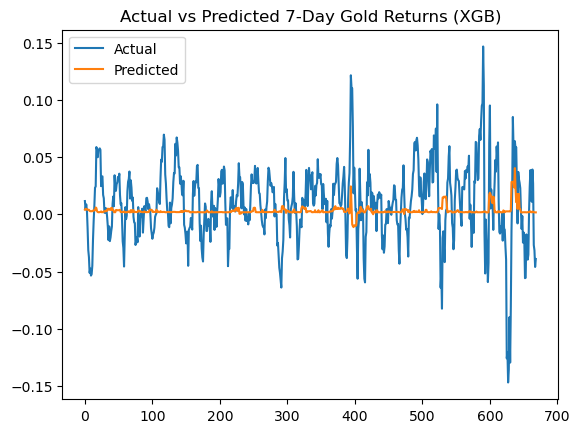

In [136]:
#VISUALIZATIONS
plt.plot(Y_test.values, label='Actual')
plt.plot(xgb_pred, label='Predicted')
plt.title('Actual vs Predicted 7-Day Gold Returns (XGB)')
plt.legend()
plt.show()

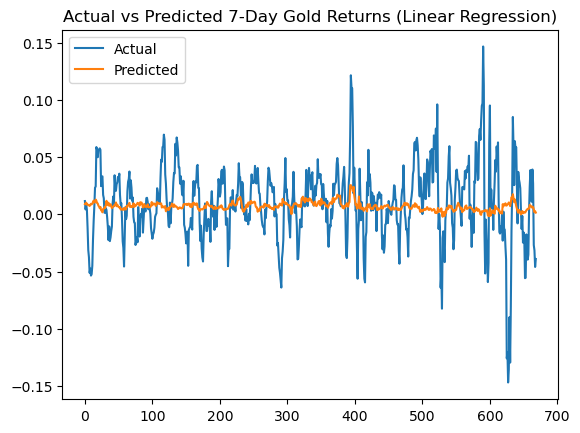

In [137]:
plt.plot(Y_test.values, label='Actual')
plt.plot(lr_pred, label='Predicted')
plt.title('Actual vs Predicted 7-Day Gold Returns (Linear Regression)')
plt.legend()
plt.show()

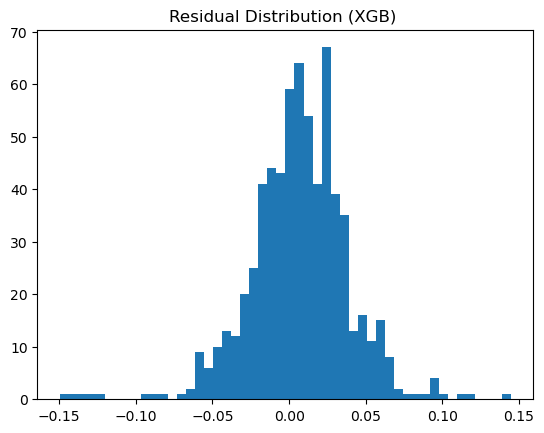

In [138]:
residualsxgb=Y_test-xgb_pred
plt.hist(residuals, bins=50)
plt.title('Residual Distribution (XGB) ')
plt.show()

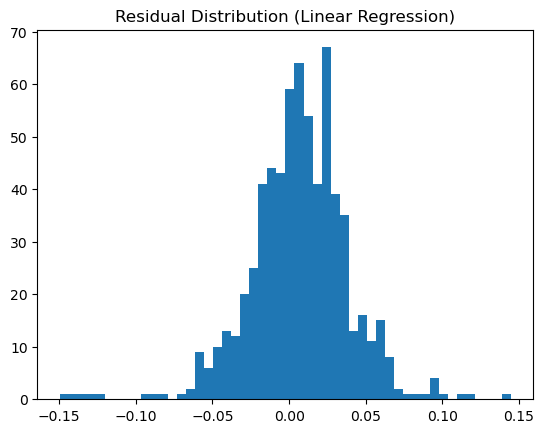

In [139]:
residualsLR=Y_test-lr_pred
plt.hist(residuals, bins=50)
plt.title('Residual Distribution (Linear Regression)')
plt.show()

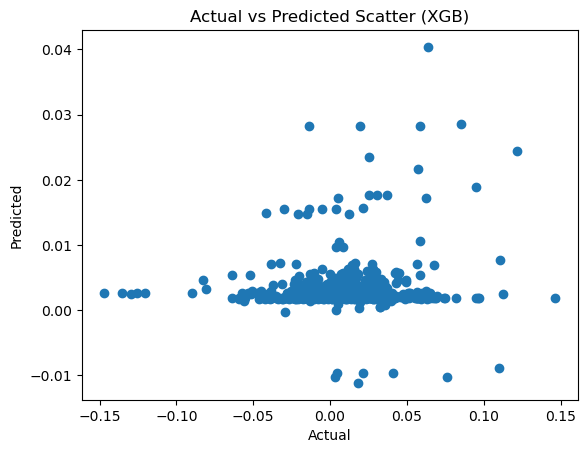

In [140]:
plt.scatter(Y_test, xgb_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Scatter (XGB)')
plt.show()

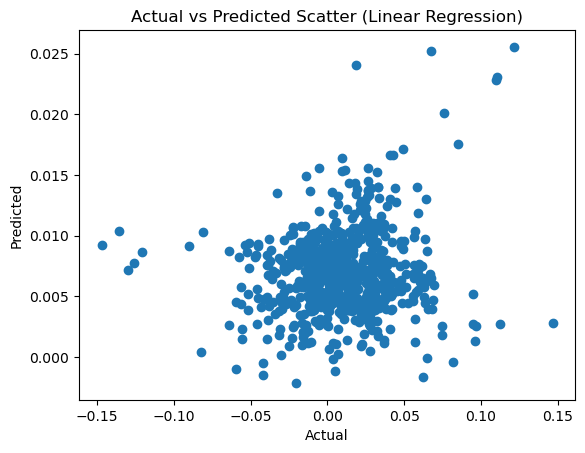

In [141]:
plt.scatter(Y_test, lr_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Scatter (Linear Regression)')
plt.show()

In [145]:
#XGB IMPORTANCE
importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
importance=importance.sort_values(ascending=False)
print(importance)

FEDFUNDS_lag90        0.133374
Gold_roll7            0.126932
FEDFUNDS_lag60        0.114104
SP500_vol7            0.098057
Gold_vol7             0.085397
SP500_roll7           0.075589
USD_roll7             0.073544
SP500_lag1            0.066275
USD_vol7              0.058498
USD_lag1              0.048023
SP500_lag5            0.046253
CPI_ret               0.044331
USD_lag5              0.029622
SP500_lag10           0.000000
FEDFUNDS_chg_lag60    0.000000
USDxSP500             0.000000
dtype: float32


In [146]:
#lINEAR REGRESSION COEFFICIENTS
coef_df=pd.DataFrame({'Feature': final_features, 'Coefficient':lr.coef_})
print(coef_df.sort_values(by='Coefficient', ascending=False))

               Feature  Coefficient
12            USD_vol7     0.628105
0              CPI_ret     0.532788
11          SP500_vol7     0.254956
1             USD_lag1     0.091456
4          SP500_lag10     0.058212
14  FEDFUNDS_chg_lag60     0.015663
6       FEDFUNDS_lag90     0.008413
5       FEDFUNDS_lag60    -0.006830
13          SP500_lag1    -0.014366
3           SP500_lag5    -0.026883
2             USD_lag5    -0.034523
10           Gold_vol7    -0.220631
9            USD_roll7    -0.294024
8          SP500_roll7    -0.305398
7           Gold_roll7    -0.382957
15           USDxSP500    -7.150018


## FINDINGS

### Finding 1
Feature Engineering contributed more performance gains than increasing model complexity.

### Finding 2
Linear Regression generalized more directionally 

### Finding 3
XGBoost reduced prediction error but did not improve directional forecasting.

### Finding 4
Market features contributed more predictive information than macroeconomic variables.

### Finding 5
Prediction quality varied substantially across splits, suggesting sensitivity in financial forecasting

## LIMITATIONS

### Limitation 1
Weak signal financial environment.

### Limitation 2
No sentiment/news information

### Limitation 3
Models struggled with extreme market movements.

### Limitation 4
Performance instability across splits suggest changes in market.

In [143]:
lr_final=LinearRegression()
lr_final.fit(X,Y)
xgb_final=XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.03, random_state=8)
xgb_final.fit(X,Y)
joblib.dump(lr_final, 'linear_model.pkl')
joblib.dump(xgb_final, 'xgb_model.pkl')
joblib.dump(final_features, 'features.pkl')
df_model.to_csv('gold_final.csv', index=True)